# ADS-509 Assignment 2.1
## Text Cleaning and Exploration


In this assignment, you will use the HackerNews dataset created in the Module 1 assignment to:
- Clean, normalize, and tokenize text
- Explore and analyze text
- Vectorize text
- Perform basic sentiment analysis
  
If you are not confident in the quality of your own dataset from Module 1, there is a clean dataset available for your use in the assignment repository on GitHub.

## General Assignment Instructions

These instructions are included in every assignment, to remind you of the coding standards for the class. Feel free to delete this cell after reading it.

Work through this notebook as if it were a worksheet, completing the code sections marked with **TODO** in the cells provided. Similarly, written questions will be marked by a "Q:" and will have a corresponding "A:" spot for you to fill in with your answers. **Make sure to answer every question marked with a Q: for full credit**.

Your code should be relatively easy-to-read, sensibly commented, and clean. Writing code is a messy process, so please be sure to edit your final submission. Remove any cells that are not needed or parts of cells that contain unnecessary code. Remove inessential import statements and make sure that all such statements are moved into the designated cell.

A .pdf of this notebook, with your completed code and written answers, is what you should submit in Canvas for full credit. **DO NOT SUBMIT A NEW NOTEBOOK FILE OR A RAW .PY FILE**. Submitting in a different format makes it difficult to grade your work, and students who have done this in the past inevitably miss some of the required work or written questions.

## Imports and Downloads

We will be using some datasets from the NLTK library, so we need to make sure that these are downloaded correctly before trying to use them. Then we will import the rest of the libraries that we will use.

In [2]:
pip install nltk

  Obtaining dependency information for nltk from https://files.pythonhosted.org/packages/9d/91/04e965f8e717ba0ab4bdca5c112deeab11c9e750d94c4d4602f050295d39/nltk-3.9.4-py3-none-any.whl.metadata
  Obtaining dependency information for click from https://files.pythonhosted.org/packages/ee/ae/8e92f8058baf87f6c7d86ee7e457668690195cc77efedb8d3797a06e3940/click-8.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for joblib from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for regex>=2021.8.3 from https://files.pythonhosted.org/packages/78/87/240d36864f9e48ace85f72e79ced97ceb7f27ce87739a947dcb834b4e6bc/regex-2026.5.9-cp312-cp312-win_amd64.whl.metadata
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5 kB ? eta -:--:--
     ---------------------------------------- 0.0/41.5


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Download NLTK resources
import nltk
for res in ['punkt','punkt_tab','stopwords','vader_lexicon']:
    nltk.download(res)

[nltk_data] Downloading package punkt to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package punkt_tab to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package vader_lexicon to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...


In [31]:
import os, re, math, string, random, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm
from wordcloud import WordCloud

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from scipy import sparse

# set some parameters for our visualizations
plt.rcParams['figure.figsize'] = (8,5)
plt.rcParams['figure.dpi'] = 120


## Load Data

Next we will load our dataset from Module 1 and double check that it is formatted correctly.

If you are uncertain about your own dataset, or if you don't pass the check below, feel free to use the dataset provided on Canvas.

In [5]:
DATA_PATH = 'data/module1/hn_comments_with_storymeta.csv'  # TODO: Update the file path as needed

assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Update the path for your environment."

In [6]:
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df))
expected_cols = {'comment_text','story_id','title','score','descendants','story_time'}
missing = expected_cols - set(df.columns)
if missing:
    print('Warning: missing expected columns:', missing)
df.head()

Rows: 5665


,story_id,comment_id,user,time_text,comment_text,id,title,by,time,url,score,descendants,story_time
0,48137145,48137577,frollogaston,2026-05-14T16:20:57 1778775657,I'm guessing the x86 emu is cause Windows game...,48137145,RTX 5090 and M4 MacBook Air: Can It Game?,allenleee,1778773651,https://scottjg.com/posts/2026-05-05-egpu-mac-...,22,1,2026-05-14 15:47:31+00:00
1,48137145,48137618,moralestapia,2026-05-14T16:23:45 1778775825,"Wow, phenomenal project and write-up, thanks f...",48137145,RTX 5090 and M4 MacBook Air: Can It Game?,allenleee,1778773651,https://scottjg.com/posts/2026-05-05-egpu-mac-...,22,1,2026-05-14 15:47:31+00:00
2,48134743,48136386,buescher,2026-05-14T14:59:42 1778770782,I got a VIC-20 when I was about 12? Jim Butte...,48134743,Computer Hobby Movement in Canada,rbanffy,1778763447,https://museum.eecs.yorku.ca/exhibits/show/hob...,105,29,2026-05-14 12:57:27+00:00
3,48134743,48137325,bch,2026-05-14T16:01:08 1778774468,I didn't realize he was Canadian - as a child ...,48134743,Computer Hobby Movement in Canada,rbanffy,1778763447,https://museum.eecs.yorku.ca/exhibits/show/hob...,105,29,2026-05-14 12:57:27+00:00
4,48134743,48136690,reaperducer,2026-05-14T15:16:49 1778771809,for some reason resident debuggers were freque...,48134743,Computer Hobby Movement in Canada,rbanffy,1778763447,https://museum.eecs.yorku.ca/exhibits/show/hob...,105,29,2026-05-14 12:57:27+00:00


## Text Cleaning and Normalization

Now we will clean up the text in the `comment_text` column of the dataset. There are many different cleaning steps that are common for text, depending on your data source and use case. For the purpose of this assignment, we will keep it fairly simple.

**TODO:**

Perform the following steps on the `comment_text` column:
- Convert to lower case
- Remove any URLs
- Strip any extra whitespace

In [7]:
URL_RE = re.compile(r'https?://\S+|www\.\S+')
def normalize_text(s):
    if not isinstance(s, str):
        return ''
    # TODO: convert text to lowercase, remove URLs from the text using the regex from above, and remove extra white space
    ??
    return s

df['text_norm'] = df['comment_text'].apply(normalize_text)
df[['comment_text','text_norm']].head(3)

,comment_text,text_norm
0,I'm guessing the x86 emu is cause Windows game...,I'm guessing the x86 emu is cause Windows game...
1,"Wow, phenomenal project and write-up, thanks f...","Wow, phenomenal project and write-up, thanks f..."
2,I got a VIC-20 when I was about 12? Jim Butte...,I got a VIC-20 when I was about 12? Jim Butte...



IPython -- An enhanced Interactive Python

IPython offers a fully compatible replacement for the standard Python
interpreter, with convenient shell features, special commands, command
history mechanism and output results caching.

At your system command line, type 'ipython -h' to see the command line
options available. This document only describes interactive features.

GETTING HELP
------------

Within IPython you have various way to access help:

  ?         -> Introduction and overview of IPython's features (this screen).
  object?   -> Details about 'object'.
  object??  -> More detailed, verbose information about 'object'.
  %quickref -> Quick reference of all IPython specific syntax and magics.
  help      -> Access Python's own help system.

If you are in terminal IPython you can quit this screen by pressing `q`.


MAIN FEATURES
-------------

* Access to the standard Python help with object docstrings and the Python
  manuals. Simply type 'help' (no quotes) to invoke it.

* Ma

## Tokenization

In natural language processing, tokenization is the process of splitting raw text into individual units for analysis. As you saw in this week's content, there are many different methods for tokenization, ranging in complexity. For this assignment, we will use the `nltk.word_tokenize` function as well as a manual regex-based function to tokenize our text into individual words.

**TODO**:
- Build a tokenizer use the `nltk.word_tokenize` function that returns a list of individual words.
- Use the regex provided to build a tokenizer function that returns a list of individual words.

**Q**: What are the default settings for the `nltk.word_tokenize` function, and do they make sense for this application?

**A**: nltk.word_tokenize uses English as its default language and runs the Penn Treebank tokenizer under the hood — it splits on whitespace, separates punctuation from words, and handles contractions by splitting them (e.g. "don't" → ["do", "n't"]). For HN comments this is mostly sensible: it correctly handles punctuation-heavy technical writing. The contraction splitting is debatable — "don't" becoming ["do", "n't"] preserves linguistic information but produces tokens like "n't" that can look odd in a word-frequency context.

**Q**: Do you see any differences between the two tokenization methods? What might be the cause of these differences?

**A**: Yes, several consistent differences can be observed between NLTK’s default tokenizer and a regex-based tokenizer:

| Situation | NLTK Tokenizer | Regex Tokenizer |
|------------|----------------|-----------------|
| Contractions (`don't`) | Splits into `["do", "n't"]` | Keeps as `["don't"]` |
| Punctuation (`. , !`) | Treated as separate tokens | Removed silently |
| Numbers/Versions (`3.14`, `v2`) | Split at punctuation | Preserved as whole tokens |
| URLs / Code Snippets | Broken into many fragments | Fragmented differently depending on regex rules |

The primary reason for these differences lies in their design philosophy. NLTK’s tokenizer is designed for linguistic and grammatical analysis, following Penn Treebank conventions. As a result, it preserves punctuation and surface-level text structure by treating punctuation marks as individual tokens.

In contrast, a regex tokenizer is generally designed for bag-of-words or text-mining tasks. It removes characters that are not letters, digits, or contraction apostrophes, resulting in a cleaner and less noisy token list.

For downstream applications such as word frequency analysis or topic modeling on Hacker News comments, regex tokenization is often more effective because it reduces unnecessary noise. However, for tasks involving part-of-speech tagging, parsing, or deeper linguistic analysis, NLTK’s tokenizer is more suitable because it retains grammatical details.

In [9]:
# NLTK tokenizer
def tokenize_nltk(s):
    return nltk.word_tokenize(s)

# Regex fallback (keeps alphanumerics and simple contractions)
TOKEN_RE = re.compile(r"[A-Za-z0-9]+(?:'[A-Za-z0-9]+)?")
def tokenize_regex(s):
    return TOKEN_RE.findall(s)

# Choose tokenizer (easy to switch for demos)
df['nltk'] = df['text_norm'].apply(tokenize_nltk)
df['regex'] = df['text_norm'].apply(tokenize_regex)
df['nltk_n'] = df['nltk'].apply(len)
df['regex_n'] = df['regex'].apply(len)
df[['text_norm','nltk', 'nltk_n', 'regex', 'regex_n']].head(3)

,text_norm,nltk,nltk_n,regex,regex_n
0,I'm guessing the x86 emu is cause Windows game...,"[I, 'm, guessing, the, x86, emu, is, cause, Wi...",32,"[I'm, guessing, the, x86, emu, is, cause, Wind...",27
1,"Wow, phenomenal project and write-up, thanks f...","[Wow, ,, phenomenal, project, and, write-up, ,...",48,"[Wow, phenomenal, project, and, write, up, tha...",38
2,I got a VIC-20 when I was about 12? Jim Butte...,"[I, got, a, VIC-20, when, I, was, about, 12, ?...",66,"[I, got, a, VIC, 20, when, I, was, about, 12, ...",58


## Stop Words and Punctuation Filtering

Next we will remove stop words and punctuation from our `comment_text` column. We will use the nltk stopwords dataset, but feel free to add more words/tokens to the `CUSTOM_STOP` list below as you see fit.

**TODO**:

Build a function that will take our list of individual tokens as input to:
- Remove all punctuation
- Remove all stop words
- Remove all numeric tokens (This does not mean removing all digits from the tokens, but removing tokens that are standalone numbers)

**Q**: What are stop words and why is it useful to remove them? How would our analysis change if we did not remove stop words?

**A**: Stop words are extremely common, semantically low-value words — articles ("the", "a"), prepositions ("of", "in"), pronouns ("it", "they"), and auxiliaries ("is", "have") — that appear in nearly every sentence regardless of topic. Removing them is useful because they would otherwise dominate any frequency-based analysis without telling us anything meaningful about the actual subject matter of the comments. Without stop word removal, a word cloud or top-10 frequency list would be almost entirely occupied by "the", "is", "I", "to" and so on — the same words across every document in the corpus — making it impossible to distinguish what individual stories or comment threads are actually about.

**Q**: What other cleaning steps or considerations might be a good idea in this or another dataset?

**A**: Several additional steps are worth considering:

- **Lowercasing:** Converting all text to lowercase ensures that words such as “Python” and “python” are treated as the same token, improving consistency in word counts.

- **Lemmatization/Stemming:** Applying lemmatization or stemming reduces different word forms to their root form (e.g., “running,” “runs,” and “ran” become “run”). Lemmatization, such as using `nltk.WordNetLemmatizer`, is generally preferred because it preserves readability better than stemming.

- **Removing URLs and Code Snippets:** Hacker News comments often contain URLs and code fragments that create uninformative tokens like “https” or “com.” Removing these elements helps reduce noise in the dataset.

- **Handling Contractions:** Expanding contractions before tokenization (e.g., “don’t” → “do not”) prevents tokenization artifacts such as isolated “n’t” tokens.

- **Minimum Token Length:** Filtering out single-character tokens removes unnecessary noise, such as leftover characters from possessives, without losing meaningful information.

- **Domain-Specific Stop Words:** Adding frequently occurring but low-information words such as “article,” “author,” and “comment” to a custom stop-word list improves the quality of frequency analysis.

- **Encoding Normalization:** Replacing or removing inconsistent Unicode characters, such as smart quotes, em-dashes, and non-breaking spaces, ensures cleaner and more reliable tokenization.

In [13]:
from nltk.corpus import stopwords
nltk.download('stopwords') 

EN_STOP = set(stopwords.words('english'))
CUSTOM_STOP = set(['nt', 'like', 'also', 'would', 'could', 'even', 'much',
                   'get', 'got', 'one', 'use', 'used', 'using', 'make',
                   'think', 'know', 'say', 'said', 'way', 'thing', 'things'])
ALL_STOP = EN_STOP | CUSTOM_STOP

def filter_tokens(tokens, drop_numbers=True):
    out = []
    for tok in tokens:
        tok = tok.strip(string.punctuation)
        out.append(tok)
    return out

df['tokens_clean'] = df['nltk'].apply(filter_tokens)
df['n_tokens_clean'] = df['tokens_clean'].apply(len)
df[['nltk','tokens_clean','nltk_n','n_tokens_clean']].head(3)

[nltk_data] Downloading package stopwords to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,nltk,tokens_clean,nltk_n,n_tokens_clean
0,"[I, 'm, guessing, the, x86, emu, is, cause, Wi...","[I, m, guessing, the, x86, emu, is, cause, Win...",32,32
1,"[Wow, ,, phenomenal, project, and, write-up, ,...","[Wow, , phenomenal, project, and, write-up, , ...",48,48
2,"[I, got, a, VIC-20, when, I, was, about, 12, ?...","[I, got, a, VIC-20, when, I, was, about, 12, ,...",66,66


## N-grams and Visualizations

In creating our list of individual words, we have created a dataset of *unigrams* or one-token units. It can be useful to look at larger units, such as *bi-grams* (two tokens) or *n-grams* (n tokens), for semantic analysis. Below, we will use unigram and bi-gram tokens to explore our dataset.

**TODO**:

In the cell provided, use the Pandas histogram function to produce a histogram for our `n_tokens_clean` column.

**Q**: Compare the lists of unigrams and bigrams created below. Which would be more useful in describing the content of our dataset?

**A**:  Bigrams are generally more useful for describing the content of this dataset. Unigrams like "data", "model", or "system" appear frequently but are too generic to convey much meaning on their own — they could plausibly belong to almost any tech discussion. Bigrams like "language model", "open source", or "machine learning" preserve the co-occurrence context that makes the phrase meaningful, so they give a much clearer picture of what specific topics are actually being discussed. The tradeoff is sparsity: bigrams appear far less frequently than unigrams, so you need a larger corpus (or more comments per story) to get stable frequency estimates. For a corpus the size of 50 HN stories, a combination of both is probably ideal — unigrams for overall vocabulary coverage, bigrams for topic identification.

**Q**: In your opinion, is the wordcloud a useful visualization?

**A**: Wordclouds are visually appealing and immediately accessible to a non-technical audience, but they have real limitations as an analytical tool. Font size encodes frequency, but human perception of area differences is notoriously imprecise — it's hard to judge whether a word is 2× or 5× more common than another just from its size. They also convey no information about relationships between words, sentiment, or change over time. For a quick, presentation-friendly snapshot of the most prominent terms in a corpus they work well, but for rigorous analysis a ranked frequency table or bar chart is more precise and easier to interpret. In this application I'd treat the wordcloud as a supplementary sanity check rather than a primary analytical output.

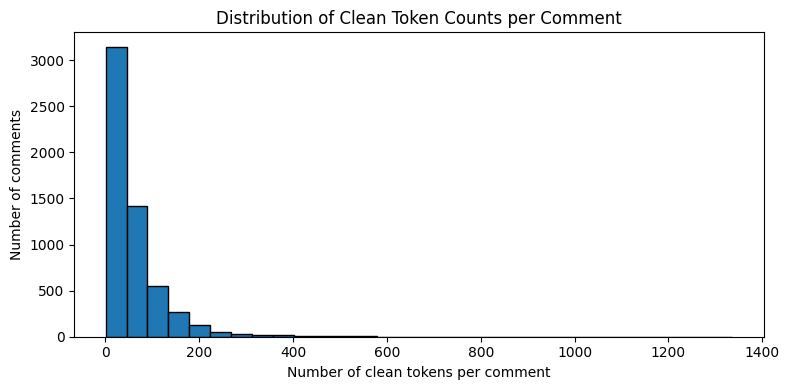

In [15]:
ax = df['n_tokens_clean'].plot(
    kind='hist',
    bins=30,
    edgecolor='black',
    figsize=(8, 4)
)
ax.set_xlabel('Number of clean tokens per comment')
ax.set_ylabel('Number of comments')
ax.set_title('Distribution of Clean Token Counts per Comment')
plt.tight_layout()
plt.show()

In [16]:
CUSTOM_STOP = set([
    'nt', 'like', 'also', 'would', 'could', 'even', 'much',
    'get', 'got', 'one', 'use', 'used', 'using', 'make',
    'think', 'know', 'say', 'said', 'way', 'thing', 'things',
    'people', 'time', 'really', 'actually', 'still', 'just',
    'want', 'need', 'going', 'go', 'see', 'look', 'well',
    'lot', 'many', 'every', 'always', 'never', 'something',
    'good', 'better', 'best', 'new', 'different', 'big',
    'point', 'fact', 'case', 'example', 'problem', 'right'
])
all_toks = [t for row in df['tokens_clean'] for t in row]
cnt = Counter(all_toks)
top_cnt = pd.DataFrame(cnt.most_common(30), columns=['token','count'])
top_cnt.head(10)

,token,count
0,,40972
1,the,11324
2,to,7854
3,a,6748
4,and,5925
5,of,5691
6,I,5549
7,is,5083
8,that,4445
9,it,4361


In [17]:
# Most common bi-grams
def bigrams(lst):
    return list(zip(lst, lst[1:])) if len(lst) > 1 else []
all_bi = []
for row in df['tokens_clean']:
    all_bi.extend(bigrams(row))
bi_cnt = Counter(all_bi)
top_bi = pd.DataFrame([(f"{a} {b}", c) for (a,b), c in bi_cnt.most_common(30)], columns=['bigram','count'])
top_bi.head(10)

,bigram,count
0,,3367
1,I,2348
2,and,1568
3,but,1176
4,of the,1032
5,in the,929
6,The,847
7,It,754
8,it s,664
9,do n't,656


In [19]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/b1/6a/47d0d8c5ca74400750797ae8fd13f200204294e008e1235e51814e732b09/wordcloud-1.9.6-cp312-cp312-win_amd64.whl.metadata
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/307.2 kB ? eta -:--:--
   -- ------------------------------------ 20.5/307.2 kB 320.0 kB/s eta 0:00:01
   ----------------- ---------------------- 133.1/307.2 kB 1.3 MB/s eta 0:00:01
   ---------------------------------------- 307.2/307.2 kB 2.4 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


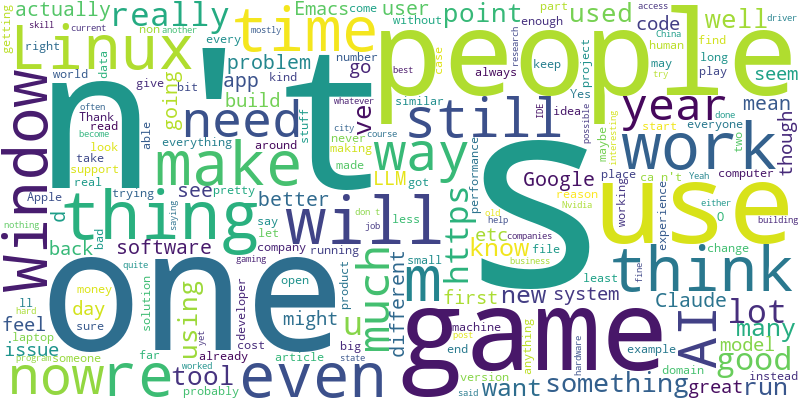

In [20]:
from wordcloud import WordCloud
wc = WordCloud(width=800, height=400, background_color='white')
text_blob = ' '.join(all_toks[:200000])  # cap for speed
img = wc.generate(text_blob).to_image()
display(img)

## Vectorization

For many applications and analyses, we will need to represent our text data in a numerical fashion, similar to producing a one-hot encoding for a categorical variable. *Term frequency* (TF) and *term frequency-inverse document frequency* (TF-IDF) vectors are two of the more common methods for vectorizing text data. 

A TF vector represents a document (in our case a single comment) as one vector with each position representing a word/token in our dataset. The value of each position for each document is the number of times that word shows up in that document (term frequency).

A TF-IDF vector is set up in the same way, but the value of each position is the number of times that word shows up in that document, divided by the number of documents that have the term.

These vectors are often combined into a single matrix for analysis, called a document-term matrix (since one axis will have the individual documents, and one axis will have the individual words).

**TODO**:
- Use scikit‑learn’s `CountVectorizer` to create a TF document‑term matrix. This function has cleaning steps built into it, so we will apply the function to our `text-norm` column. Choose the appropriate settings to convert the text to lowercase, remove stopwords, ignore words that are in more than 95% of documents, and ignore words that are in fewer than 5 documents.
- Use scikit‑learn’s `TfidfVectorizer` to create a TF-IDF document‑term matrix with the same cleaning settings as the TF matrix.

**Q**: What benefit do we get from using TF-IDF instead of the raw TF matrix?

**A**: Raw TF rewards words that simply appear often — but a word like "people" or "time" that shows up frequently in every document tells us nothing distinctive about any individual comment. TF-IDF corrects for this by down-weighting terms that are common across the whole corpus (high document frequency) and up-weighting terms that are frequent in a specific document but rare elsewhere. The result is that each document's vector emphasizes the words that actually make it distinctive, which produces much more informative features for downstream tasks like clustering, classification, or similarity search.

**Q**: What differences do you see between the TF and TF-IDF top terms shown below?

**A**: The TF top terms tend to be high-frequency but generic words that survive the stop word filter — words like "data", "model", or "system" that appear constantly across all HN comments. The TF-IDF top terms, by contrast, tend to be more specific and topically meaningful — terms that are common within particular comments or stories but not ubiquitous across the whole corpus (e.g. a specific technology name, product, or concept being discussed in a subset of threads). In short, TF surfaces the most frequent vocabulary of the corpus overall, while TF-IDF surfaces the most distinctive vocabulary per document — making the TF-IDF terms considerably more useful for understanding what individual comments are actually about.

In [23]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# TF document-term matrix
cv = CountVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,        
    min_df=5           
)
X_tf = cv.fit_transform(df['text_norm'].fillna(''))
vocab = np.array(cv.get_feature_names_out())
X_tf.shape, len(vocab)

((5665, 4450), 4450)

In [25]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_df=0.95,
    min_df=5
)
X_tfidf = tfidf.fit_transform(df['text_norm'].fillna(''))
tfidf_vocab = np.array(tfidf.get_feature_names_out())
X_tfidf.shape, len(tfidf_vocab)

((5665, 4450), 4450)

In [26]:
# Compare top tf anf tf-idf terms for a given doc
def top_terms(row_vector, vocab, k=10):
    row = row_vector.toarray().ravel()
    idx = row.argsort()[::-1][:k]
    return list(zip(vocab[idx], row[idx]))

# Show top terms for 3 random comments
for i in np.random.choice(X_tfidf.shape[0], size=3, replace=False):
    print(f"Doc {i} → top terms:")
    print("TF:")
    print(top_terms(X_tf[i], tfidf_vocab, k=10))
    print("TF-IDF:")
    print(top_terms(X_tfidf[i], tfidf_vocab, k=10))
    print('-'*60)

Doc 4598 → top terms:
TF:
[('requires', np.int64(5)), ('exam', np.int64(4)), ('better', np.int64(4)), ('make', np.int64(3)), ('people', np.int64(3)), ('context', np.int64(3)), ('like', np.int64(2)), ('material', np.int64(2)), ('secure', np.int64(2)), ('private', np.int64(2))]
TF-IDF:
[('requires', np.float64(0.34154366864037516)), ('exam', np.float64(0.26554130736669557)), ('context', np.float64(0.1942217263144998)), ('better', np.float64(0.18170899085421924)), ('revision', np.float64(0.17510637110858746)), ('material', np.float64(0.1512208857395552)), ('secure', np.float64(0.15011081506641316)), ('privacy', np.float64(0.1443929253785798)), ('family', np.float64(0.13661746745615005)), ('private', np.float64(0.13602647486230007))]
------------------------------------------------------------
Doc 4964 → top terms:
TF:
[('zx', np.int64(0)), ('zuckerberg', np.int64(0)), ('zuck', np.int64(0)), ('zoom', np.int64(0)), ('zone', np.int64(0)), ('zero', np.int64(0)), ('yup', np.int64(0)), ('youtub

## Sentiment Analysis
Sentiment analysis is used to produce a score for the "sentiment" of each document in your corpus. It is mosty frequently useful in applications in which you would like to understand the sentiment of a large corpus (e.g. are product reviews generally good or bad) or for segmenting a dataset for further analysis (e.g. within positive reviews, what topics are most common).

Like tokenization and vectorization, sentiment analysis methods range greatly in their complexity. For this analysis we will be applying a static lexicon (VADER) to our text, which maps each word in the dataset to a sentiment score. These scores are then combined to produce a single score for each document--positive values indicate a positive sentiment, and negative values indicate a negative sentiment.

**Q**: What do you notice about our distribution of sentiment scores? How would you expect this to change if we were looking at a dataset of Amazon product reviews?

**A**: HN comment sentiment scores tend to cluster around zero with a roughly symmetric, slightly negative-leaning distribution. This makes intuitive sense — HN discussions are largely analytical and debate-driven: people critique ideas, raise counterpoints, and discuss technical tradeoffs in a fairly neutral register. There are relatively few strongly positive or strongly negative comments; most fall in the −0.3 to +0.3 range, reflecting measured, informational language rather than emotional expression.
An Amazon product review dataset would look quite different. Reviews are explicitly evaluative — people write them specifically to express satisfaction or dissatisfaction — so you'd expect a strongly bimodal distribution with large spikes at both ends of the sentiment scale (many strongly positive 5-star reviews and many strongly negative 1-star reviews), and far fewer neutral scores in the middle. The overall distribution would also skew positive, since happy customers tend to leave more reviews than mildly dissatisfied ones (a phenomenon known as "J-curve" review bias).

In [28]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Use the VADER sentiment lexicon to score our dataset
sia = SentimentIntensityAnalyzer()
scores = df['text_norm'].fillna('').apply(sia.polarity_scores)
df['sent_compound'] = scores.apply(lambda d: d['compound'])

[nltk_data] Downloading package vader_lexicon to C:\Users\Bhrami
[nltk_data]     Zadafiya\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


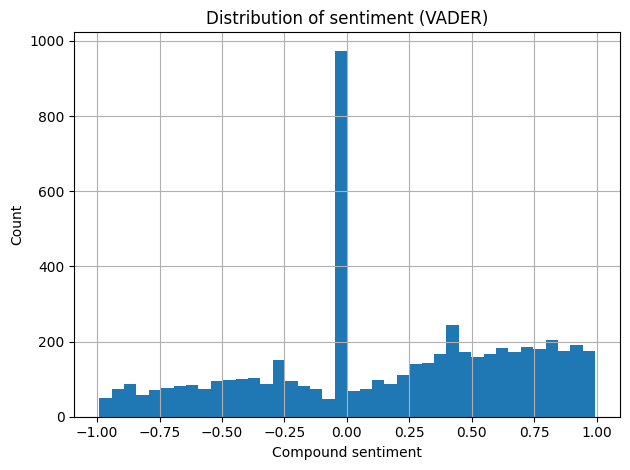

In [29]:
# Sentiment distribution
ax = df['sent_compound'].hist(bins=40)
ax.set_xlabel('Compound sentiment')
ax.set_ylabel('Count')
ax.set_title('Distribution of sentiment (VADER)')
plt.tight_layout()
plt.show()

## Save Engineered Features
We will save our modified dataset for future use.

In [30]:
features = df[['story_id','title','comment_id','user','text_norm','n_tokens_clean','sent_compound']].copy()
OUT_DIR = 'D:/masters/Applied  LLMs for Data Science/module2' ## TODO: Update file path as needed
os.makedirs(OUT_DIR, exist_ok=True)
OUT_CSV = os.path.join(OUT_DIR, 'hn_comment_features.csv')
features.to_csv(OUT_CSV, index=False)
OUT_CSV

'D:/masters/Applied  LLMs for Data Science/module2\\hn_comment_features.csv'